# Library Import

In [70]:
import cv2
import matplotlib.pyplot as plt
import warnings
from keras import Layer, Input, Sequential
from keras.src.callbacks import CSVLogger, ReduceLROnPlateau, EarlyStopping, TensorBoard
from keras.src.layers import BatchNormalization, Dense, MaxPooling2D, Dropout, Flatten, Conv2D
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras.src.optimizers import AdamW
from keras.src.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import os
from tqdm import tqdm
from sklearn.utils import shuffle
import plotly.express as px
import plotly.graph_objects as go
import itertools

warnings.filterwarnings('ignore')

Sequential = Sequential
Conv2D = Conv2D
Flatten = Flatten
Dropout = Dropout
MaxPooling2D = MaxPooling2D
Dense = Dense
Input = Input
EarlyStopping = EarlyStopping
ReduceLROnPlateau = ReduceLROnPlateau
Layers = Layer
ImageDataGenerator = ImageDataGenerator
BatchNormalization = BatchNormalization
CSVLogger = CSVLogger
Adam = AdamW
TensorBoard = TensorBoard

# PATH

In [71]:
train_path = 'dataset/training/'
PLOT_SAVE_DIR = 'output/plot/v4/'
LOG_DIR = 'output/log/v4/'
MODEL_SAVE_PATH = 'output/model/v4/cnn_model_v4.keras'
HISTORY_PATH = 'output/model/v4/train_history_v4.npy'

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.001

LABEL_MAPPING = {
    'alcohol': 0,
    'blood': 1,
    'sexual': 2,
    'traffic_accident': 3
}

class_names = ['alcohol', 'blood', 'sexual', 'traffic_accident']
nb_classes = len(class_names)

# Function to load data

In [72]:
def load_data(dataset, label_mapping, image_size=(IMAGE_SIZE)):
    images = []
    labels = []

    if isinstance(dataset, str):
        dataset = [dataset]

    for dataset_path in dataset:
        if not os.path.exists(dataset_path):
            raise FileNotFoundError(f"Dataset directory {dataset_path} not found.")

        for folder in os.listdir(dataset_path):
            if folder in label_mapping:
                label = label_mapping[folder]
            else:
                continue

            folder_path = os.path.join(dataset_path, folder)

            if not os.path.isdir(folder_path):
                continue

            for file in tqdm(os.listdir(folder_path)):
                img_path = os.path.join(folder_path, file)

                if not os.path.isfile(img_path):
                    continue

                image = cv2.imread(img_path)

                if image is None:
                    continue

                image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                image = cv2.resize(image, image_size)

                image = np.expand_dims(image, axis=-1)

                image = image / 255.0

                images.append(image)
                labels.append(label)

    images = np.array(images, dtype='float32')
    labels = np.array(labels, dtype='int')

    return images, labels

# Execute images and labels

In [73]:
images, labels = load_data(train_path, LABEL_MAPPING)

100%|██████████| 500/500 [00:01<00:00, 402.29it/s]


In [74]:
print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

Images shape: (2000, 224, 224, 1)
Labels shape: (2000,)


# Split data into training and testing sets

In [75]:
images, labels = shuffle(images, labels, random_state=10)

train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2)
test_images, val_images, test_labels, val_labels = train_test_split(test_images, test_labels, test_size=0.5)

In [76]:
train_labels_onehot = to_categorical(train_labels, num_classes=nb_classes)
val_labels_onehot = to_categorical(val_labels, num_classes=nb_classes)
test_labels_onehot = to_categorical(test_labels, num_classes=nb_classes)

In [77]:
print(f"Number of training: {train_labels.shape[0]}")
print(f"Number of validation: {val_labels.shape[0]}")
print(f"Number of testing: {test_labels.shape[0]}")
print(f"Training images are of shape: {train_images.shape}")
print(f"Training labels are of shape: {train_labels_onehot.shape}")
print(f"Validation images are of shape: {val_images.shape}")
print(f"Validation labels are of shape: {val_labels_onehot.shape}")
print(f"Test images are of shape: {test_images.shape}")
print(f"Test labels are of shape: {test_labels_onehot.shape}")

Number of training: 1600
Number of validation: 200
Number of testing: 200
Training images are of shape: (1600, 224, 224, 1)
Training labels are of shape: (1600, 4)
Validation images are of shape: (200, 224, 224, 1)
Validation labels are of shape: (200, 4)
Test images are of shape: (200, 224, 224, 1)
Test labels are of shape: (200, 4)


# Visualize dataset

In [78]:
reverse_label_mapping = {v: k for k, v in LABEL_MAPPING.items()}
class_label_names = [reverse_label_mapping[label] for label in labels]

fig = px.histogram(
    y=class_label_names,
    template='plotly_dark',
    color=class_label_names,
    title='Number of Images per Class in Train Data',
    labels={'x': 'Class Label', 'y': 'Count of Images'}
)
fig.show()

In [79]:
_, train_counts = np.unique(train_labels, return_counts=True)
_, val_counts = np.unique(val_labels, return_counts=True)
_, test_counts = np.unique(test_labels, return_counts=True)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=class_names,
    y=train_counts,
    name='Train',
    marker=dict(color='blue')
))

fig.add_trace(go.Bar(
    x=class_names,
    y=val_counts,
    name='Validation',
    marker=dict(color='green')
))

fig.add_trace(go.Bar(
    x=class_names,
    y=test_counts,
    name='Test',
    marker=dict(color='red')
))

fig.update_layout(
    title="Number of Images per Class in Train, Validation, and Test Data",
    barmode='group',
    xaxis_title="Class",
    yaxis_title="Number of Images",
    template="plotly_dark"
)

# Show the plot
fig.show()

In [80]:
fig = go.Figure(data=[go.Pie(
    labels=class_names,
    values=train_counts,
    textinfo='percent+label',
    marker=dict(colors=['blue', 'green', 'red', 'purple']),
)])

fig.update_layout(
    title="Proportion of Each Classes",
    template="plotly_dark",
)

fig.show()

# Data Augmentation

In [81]:
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1. / 255)
test_datagen = ImageDataGenerator(rescale=1. / 255)

train_generator = train_datagen.flow(train_images, train_labels, batch_size=BATCH_SIZE, shuffle=True)
valid_generator = val_datagen.flow(val_images, val_labels, batch_size=BATCH_SIZE, shuffle=False)
test_generator = test_datagen.flow(test_images, test_labels, batch_size=BATCH_SIZE, shuffle=False)

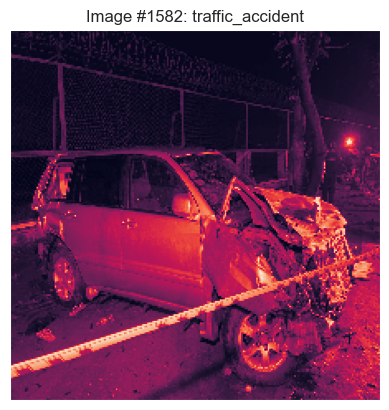

In [82]:
def display_random_image(class_names, images, labels):
    index = np.random.randint(images.shape[0])
    plt.figure()
    plt.imshow(images[index])
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.title('Image #{}: '.format(index) + class_names[labels[index]])
    plt.show()


display_random_image(class_names, train_images, train_labels)

# Display some dataset

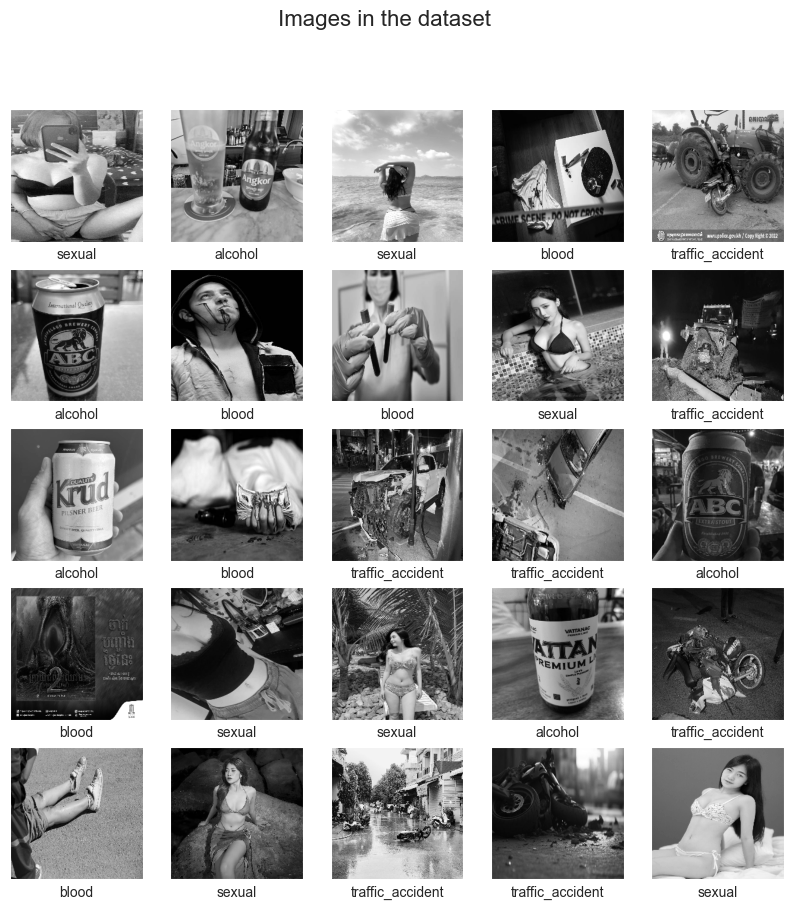

In [83]:
def display_dataset(class_names, images, labels):
    fig = plt.figure(figsize=(10, 10))
    fig.suptitle("Images in the dataset", fontsize=16)

    decoded_labels = np.argmax(labels, axis=1) if len(labels.shape) > 1 else labels

    for i in range(25):
        plt.subplot(5, 5, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.xlabel(class_names[decoded_labels[i]])
    plt.show()


display_dataset(class_names, train_images, train_labels)

# Model architecture

In [84]:
model = Sequential()

# First convolutional block
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(224, 224, 1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.2))

# Second convolutional block
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.3))

# Third convolutional block
model.add(Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.3))

# Fourth convolutional block
model.add(Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.4))

# Flatten
model.add(Flatten())

# Fully connected layers
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output layer
model.add(Dense(units=nb_classes, activation='softmax'))

# summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,268,484 (50.62 MB)

 Trainable params: 13,267,524 (50.61 MB)

 Non-trainable params: 960 (3.75 KB)

# Compile the model

In [85]:
optimizer = Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Callbacks
callbacks = [
    CSVLogger(os.path.join(LOG_DIR, 'training_log_v4.csv'), append=True),
    TensorBoard(log_dir=os.path.join(LOG_DIR, "tensorboard_logs"))
]

# Train
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=valid_generator,
    callbacks=callbacks,
    verbose=1
)

# Saved model
model.save(MODEL_SAVE_PATH)
np.save(HISTORY_PATH, history.history)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.3151 - loss: 15.1717 - val_accuracy: 0.2350 - val_loss: 8.8651
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.3199 - loss: 9.8634 - val_accuracy: 0.2600 - val_loss: 11.1604
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.3068 - loss: 3.6117 - val_accuracy: 0.2600 - val_loss: 6.1623
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.3249 - loss: 1.5167 - val_accuracy: 0.2600 - val_loss: 3.6826
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.2889 - loss: 1.4032 - val_accuracy: 0.2200 - val_loss: 2.7082
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.3036 - loss: 1.4106 - val_accuracy: 0.2250 - val_loss: 2.5083
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.2492 - loss: 1.4219 - val_accuracy: 0.2300 - val_loss: 2.5782
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.2604 - loss: 1.3961 - val_accuracy: 0.2300 -

# Evaluate the model

In [86]:
train_score = model.evaluate(train_generator, verbose=1)
valid_score = model.evaluate(valid_generator, verbose=1)
test_score = model.evaluate(test_generator, verbose=1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 230ms/step - accuracy: 0.2439 - loss: 94.6773
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - accuracy: 0.2360 - loss: 94.9678
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - accuracy: 0.2127 - loss: 106.3576
Train Loss:  93.29690551757812
Train Accuracy:  0.25687500834465027
--------------------
Validation Loss:  100.86146545410156
Validation Accuracy:  0.23000000417232513
--------------------
Test Loss:  104.6769027709961
Test Accuracy:  0.2150000035762787


In [87]:
preds = model.predict(test_generator, verbose=1)
y_pred = np.argmax(preds, axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 206ms/step


In [88]:
def plot_accuracy_loss_chart(history):
    epochs = [i for i in range(len(history.history['accuracy']))]
    fig, ax = plt.subplots(1, 2)
    train_acc = history.history['accuracy']
    train_loss = history.history['loss']
    val_acc = history.history['val_accuracy']
    val_loss = history.history['val_loss']
    fig.set_size_inches(20, 10)

    ax[0].plot(epochs, train_acc, 'go-', label='Training Accuracy')
    ax[0].plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
    ax[0].set_title('Training & Validation Accuracy')
    ax[0].legend()
    ax[0].set_xlabel("Epochs")
    ax[0].set_ylabel("Accuracy")

    ax[1].plot(epochs, train_loss, 'g-o', label='Training Loss')
    ax[1].plot(epochs, val_loss, 'r-o', label='Validation Loss')
    ax[1].set_title('Training & Validation Loss')
    ax[1].legend()
    ax[1].set_xlabel("Epochs")
    ax[1].set_ylabel("Training & Validation Loss")

    plt.show()

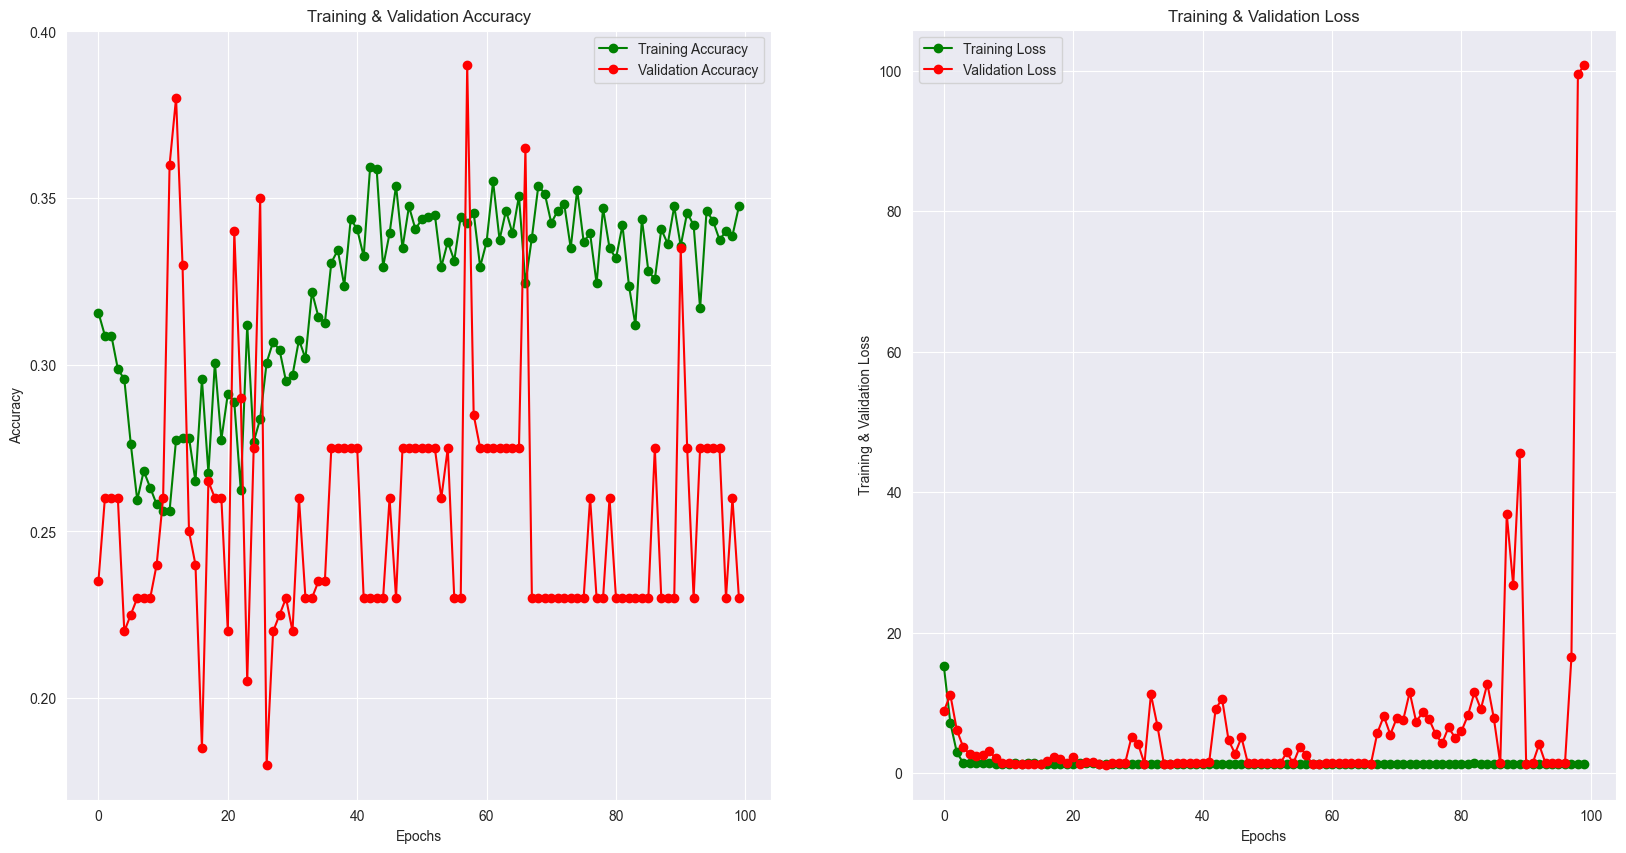

In [89]:
plot_accuracy_loss_chart(history)

In [117]:
results = model.evaluate(test_images, test_labels)

print("Loss of the model is: ", results[0])
print("Accuracy of the model is: ", results[1] * 100, "%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 218ms/step - accuracy: 0.3776 - loss: 1.3348
Loss of the model is:  1.3473870754241943
Accuracy of the model is:  36.500000953674316 %


In [110]:
classes = list(class_names)

cm = confusion_matrix(test_labels, y_pred)
cm

array([[ 0, 50,  0,  0],
       [ 0, 43,  0,  0],
       [ 0, 50,  0,  0],
       [ 0, 57,  0,  0]])

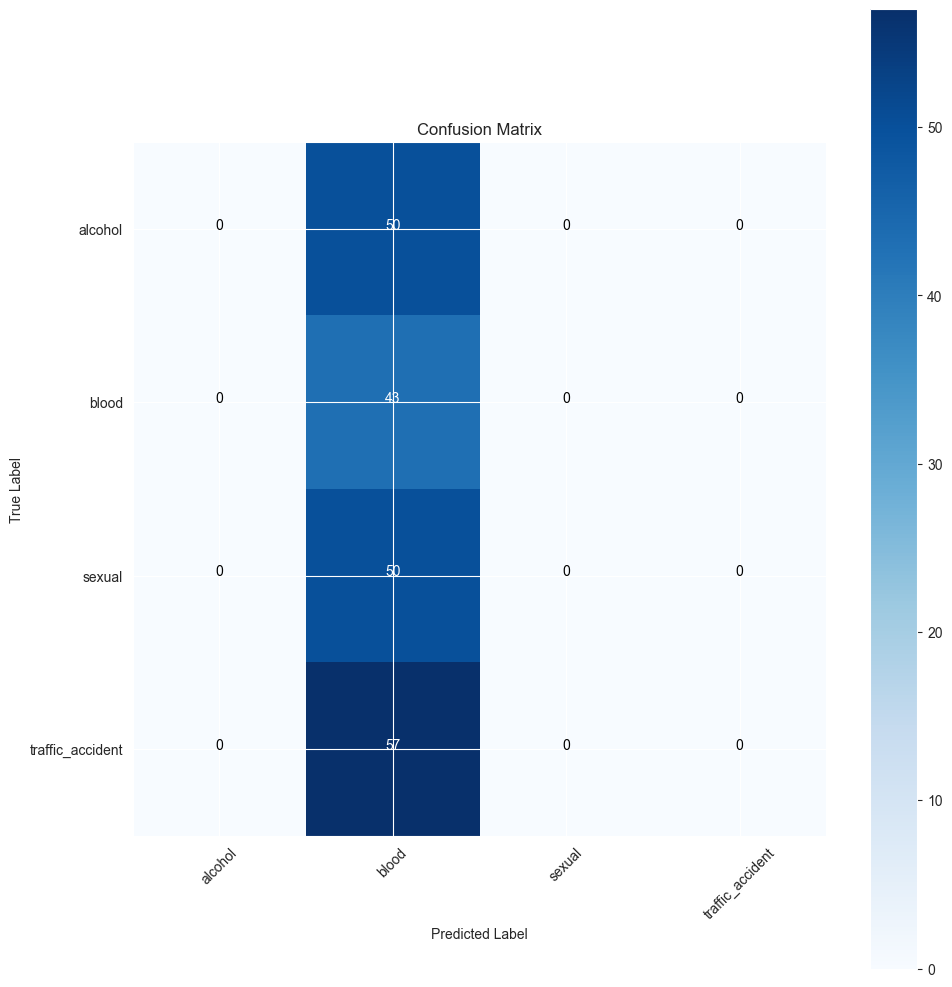

In [112]:
plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment='center', color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [116]:
print(classification_report(test_labels, y_pred, target_names=classes))

                  precision    recall  f1-score   support

         alcohol       0.00      0.00      0.00        50
           blood       0.21      1.00      0.35        43
          sexual       0.00      0.00      0.00        50
traffic_accident       0.00      0.00      0.00        57

        accuracy                           0.21       200
       macro avg       0.05      0.25      0.09       200
    weighted avg       0.05      0.21      0.08       200

